In [1]:
!pip install -q tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, Input, Activation
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

from tf_explain.core.integrated_gradients import IntegratedGradients

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

## Part A — CIFAR-10 Image Classifier

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3954s 23us/step
Training Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)


**Note on the model architecture:** classic **CAM** (Class Activation Mapping, Zhou et al.) is only
mathematically valid for networks that end in `Global Average Pooling -> single Dense(num_classes) layer`,
because CAM reconstructs the class heatmap directly from the weights of that final Dense layer. The original
notebook used `Flatten -> Dense(128) -> Dropout -> Dense(10)`, so there was no way to compute a *true*
class-discriminative CAM from it (only a generic, class-agnostic average of the feature maps, which is what
the old Cell 12 was actually doing). The architecture below fixes this by ending in GAP + a single linear
Dense layer, which supports CAM, Grad-CAM, and Integrated Gradients all at once.

In [4]:
inputs = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)

# LAST CONV LAYER (used by both Grad-CAM and CAM)
x = Conv2D(128, (3, 3), activation='relu', padding='same', name="last_conv")(x)

x = GlobalAveragePooling2D()(x)

# Linear (no activation) Dense so we can access raw logits for Grad-CAM/CAM,
# and a separate softmax Activation layer for training/prediction.
logits = Dense(10, use_bias=False, name="predictions")(x)
outputs = Activation('softmax', name="softmax_out")(logits)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_out (Activation)        │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,528 (369.25 KB)

 Trainable params: 94,528 (369.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=30,
    batch_size=64
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7382 - loss: 0.7487 - val_accuracy: 0.7130 - val_loss: 0.8370
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7435 - loss: 0.7326 - val_accuracy: 0.7159 - val_loss: 0.8311
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7482 - loss: 0.7174 - val_accuracy: 0.7164 - val_loss: 0.8282
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7534 - loss: 0.7027 - val_accuracy: 0.7175 - val_loss: 0.8231
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7590 - loss: 0.6880 - val_accuracy: 0.7195 - val_loss: 0.8191
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7643 - loss: 0.6741 - val_accuracy: 0.7224 - val_loss: 0.8163
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7692 - loss: 0.6608 - val_accuracy: 0.7239 - val_loss: 0.8124
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7742 - loss: 0.6476 - val_accuracy: 0.

In [8]:
loss, acc = model.evaluate(x_test, y_test_cat)
print("\nTest Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7438 - loss: 0.8389

Test Accuracy: 0.7437999844551086


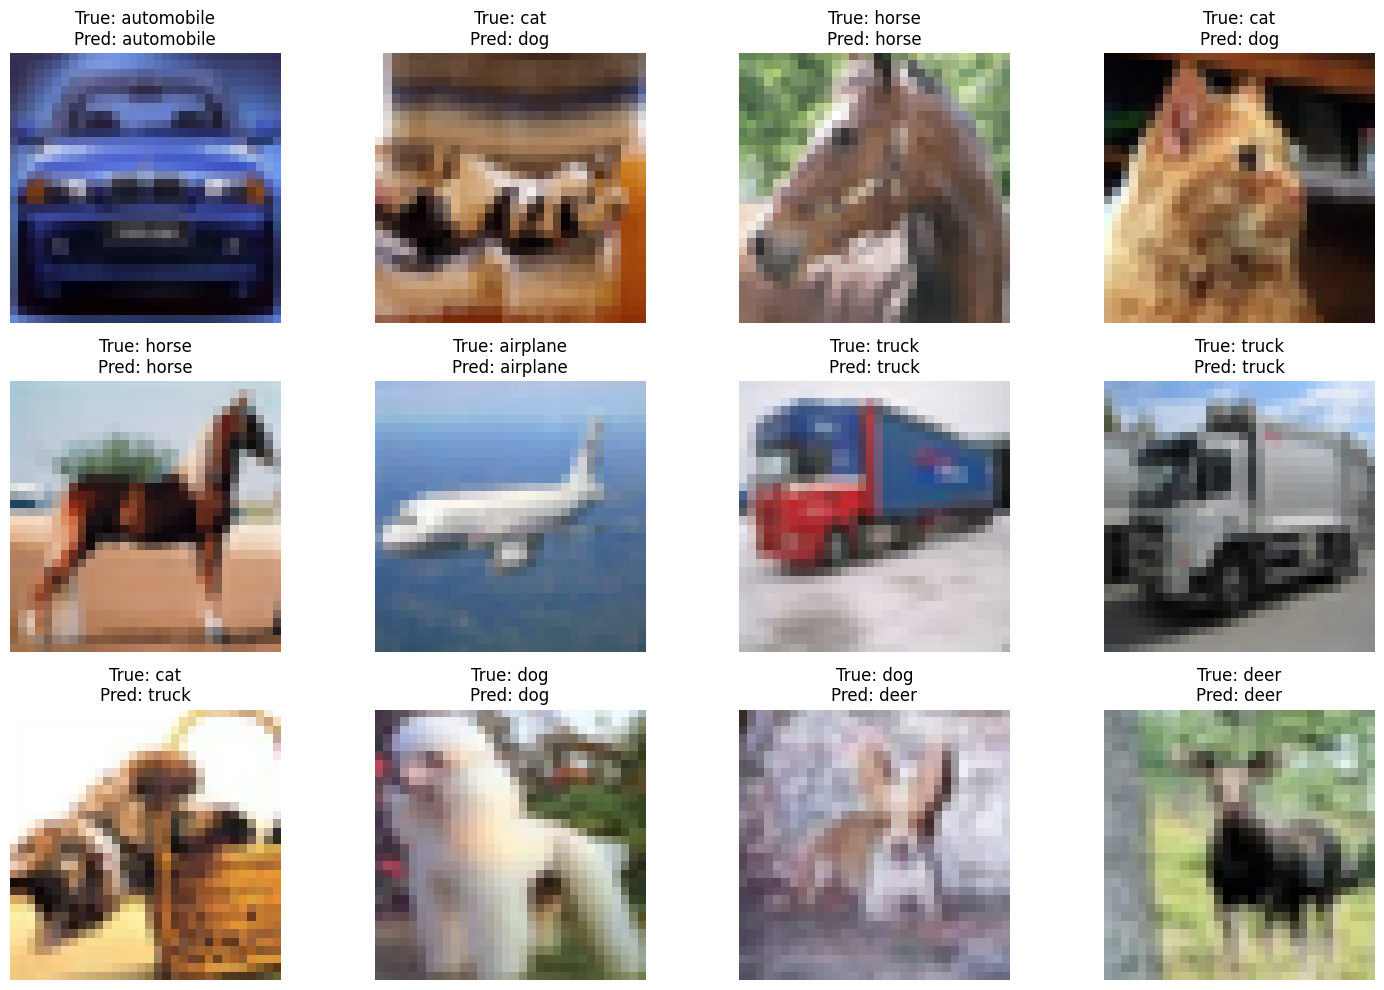

In [9]:
num_images = 12
random_indices = random.sample(range(len(x_test)), num_images)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img = x_test[idx]
    true_label = y_test[idx][0]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_class = np.argmax(pred)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Pick one image to explain.** (Previously the code silently relied on whatever the `for` loop
happened to leave in `sample_image`/`sample_label` from the visualization grid above — it worked, but it
was fragile and made the notebook confusing to re-run. Here the explained image is chosen explicitly.)

In [10]:
explain_idx = random_indices[0]
sample_image = x_test[explain_idx]
sample_label = y_test[explain_idx][0]
img_array = np.expand_dims(sample_image, axis=0)

pred_probs = model.predict(img_array, verbose=0)
predicted_class = np.argmax(pred_probs[0])

print(f"Explaining test image #{explain_idx}")
print(f"True label:      {class_names[sample_label]}")
print(f"Predicted label: {class_names[predicted_class]} (confidence {pred_probs[0][predicted_class]:.3f})")

Explaining test image #4506
True label:      automobile
Predicted label: automobile (confidence 1.000)


### Grad-CAM

In [11]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_layer_name, pred_index=None):
    """Grad-CAM computed from RAW LOGITS (pred_layer_name), not post-softmax probabilities.
    Using logits avoids the gradient-saturation issue that softmax can introduce."""
    grad_model = Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.get_layer(pred_layer_name).output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, logits = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(logits[0])
        class_channel = logits[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


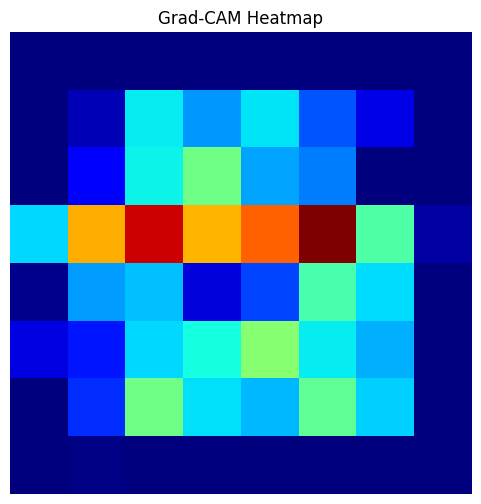

In [12]:
heatmap = make_gradcam_heatmap(
    img_array, model, "last_conv", "predictions", pred_index=predicted_class
)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

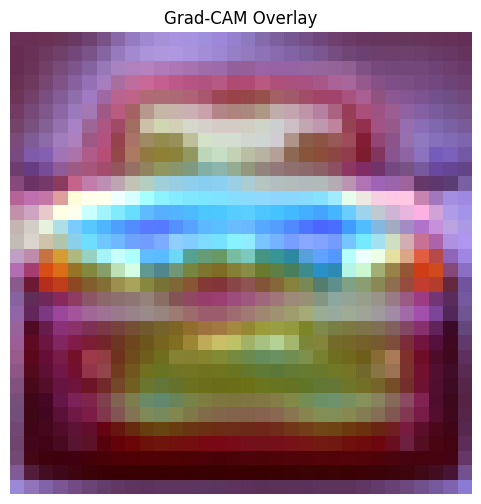

In [13]:
def overlay_heatmap(heatmap, original_img_float01, alpha=0.4):
    """original_img_float01: HxWx3 image scaled to [0,1]. Returns a clipped uint8 overlay."""
    h, w = original_img_float01.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET).astype("float32")

    base = original_img_float01 * 255.0
    superimposed = heatmap_color * alpha + base
    # IMPORTANT FIX: clip before casting to uint8, otherwise values above 255
    # wrap around instead of saturating and the overlay gets corrupted colors.
    superimposed = np.clip(superimposed, 0, 255).astype("uint8")
    return superimposed

gradcam_overlay = overlay_heatmap(heatmap, sample_image)

plt.figure(figsize=(6, 6))
plt.imshow(gradcam_overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

### CAM (Class Activation Mapping)

True CAM (Zhou et al., 2016) reconstructs the heatmap directly from the final Dense layer's weights for the
predicted class — that's what makes it *class-discriminative* (a cat image and a dog image get different
maps). This only works because the model above ends in `GlobalAveragePooling2D -> Dense(10, use_bias=False)`.

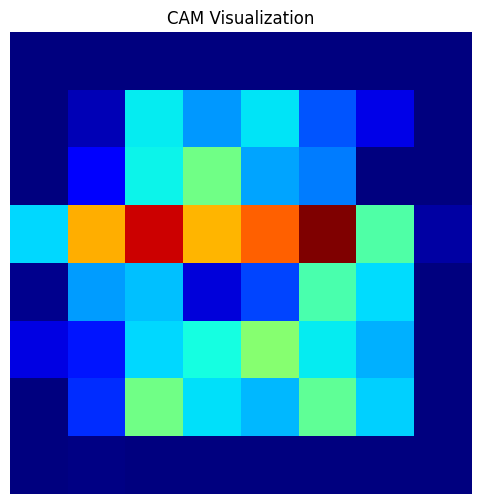

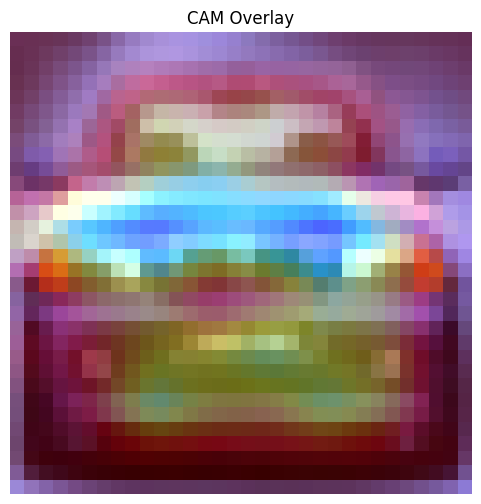

In [14]:
def make_cam_heatmap(img_array, model, last_conv_layer_name, dense_layer_name, pred_index=None):
    feature_map_model = Model(model.inputs, model.get_layer(last_conv_layer_name).output)
    feature_maps = feature_map_model.predict(img_array, verbose=0)[0]  # (h, w, channels)

    dense_weights = model.get_layer(dense_layer_name).get_weights()[0]  # (channels, num_classes)

    if pred_index is None:
        preds = model.predict(img_array, verbose=0)
        pred_index = np.argmax(preds[0])

    class_weights = dense_weights[:, pred_index]  # (channels,)

    h, w, channels = feature_maps.shape
    cam = np.dot(feature_maps.reshape(h * w, channels), class_weights).reshape(h, w)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    return cam

cam = make_cam_heatmap(img_array, model, "last_conv", "predictions", pred_index=predicted_class)

plt.figure(figsize=(6, 6))
plt.imshow(cam, cmap='jet')
plt.title("CAM Visualization")
plt.axis("off")
plt.show()

cam_overlay = overlay_heatmap(cam, sample_image)
plt.figure(figsize=(6, 6))
plt.imshow(cam_overlay)
plt.title("CAM Overlay")
plt.axis("off")
plt.show()

### Integrated Gradients

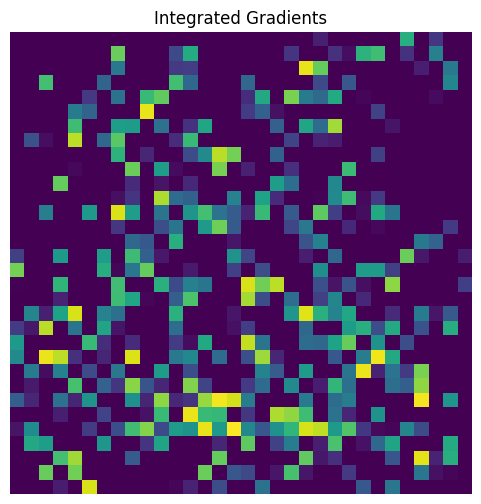

In [15]:
ig = IntegratedGradients()

ig_grid = ig.explain(
    validation_data=(img_array, None),
    model=model,
    class_index=int(predicted_class)
)

plt.figure(figsize=(6, 6))
plt.imshow(ig_grid)
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()

## Part B — Face Classifier (images captured on a mobile phone)

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Fix:** the original notebook never mounted Google Drive before reading from
`/content/drive/MyDrive/dataset/person`, which would raise a `FileNotFoundError` on a fresh runtime.
The loader below also skips non-folder entries (e.g. `.ipynb_checkpoints`) and unreadable images,
which the original silently assumed would never happen.

In [17]:
IMG_SIZE = 128
dataset_path = "/content/drive/MyDrive/dataset/person"

data = []
labels = []

people = sorted([
    p for p in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, p))
])

for label_index, person_name in enumerate(people):
    person_folder = os.path.join(dataset_path, person_name)

    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Skipping unreadable file: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        data.append(img)
        labels.append(label_index)

data = np.array(data)
labels = np.array(labels)
labels_cat = to_categorical(labels, num_classes=len(people))

print("Face Dataset Shape:", data.shape)
print("People (classes):", people)

Face Dataset Shape: (35, 128, 128, 3)
People (classes): ['al-amin', 'reeky', 'saba', 'sania', 'shawda', 'shawon', 'sifat']


In [18]:
face_inputs = Input(shape=(128, 128, 3))

f = Conv2D(32, (3, 3), activation='relu', padding='same')(face_inputs)
f = MaxPooling2D((2, 2))(f)

f = Conv2D(64, (3, 3), activation='relu', padding='same')(f)
f = MaxPooling2D((2, 2))(f)

f = Conv2D(128, (3, 3), activation='relu', padding='same', name="face_last_conv")(f)

f = GlobalAveragePooling2D()(f)

face_logits = Dense(len(people), use_bias=False, name="face_predictions")(f)
face_outputs = Activation('softmax', name="face_softmax_out")(face_logits)

face_model = Model(face_inputs, face_outputs)

face_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

face_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_last_conv (Conv2D)         │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_predictions (Dense)        │ (None, 7)              │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_softmax_out (Activation)   │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,144 (367.75 KB)

 Trainable params: 94,144 (367.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
face_model.fit(
    data,
    labels_cat,
    epochs=30,
    batch_size=8
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8571 - loss: 0.6976
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8857 - loss: 0.6576
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8571 - loss: 0.6219
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9143 - loss: 0.5929
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8857 - loss: 0.5605 
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8857 - loss: 0.5370
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8571 - loss: 0.5064
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8857 - loss: 0.4870
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8857 - loss: 0.4623 
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8571 - loss: 0.4415
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9143 - loss: 0.4288
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8571 - loss: 0.4075

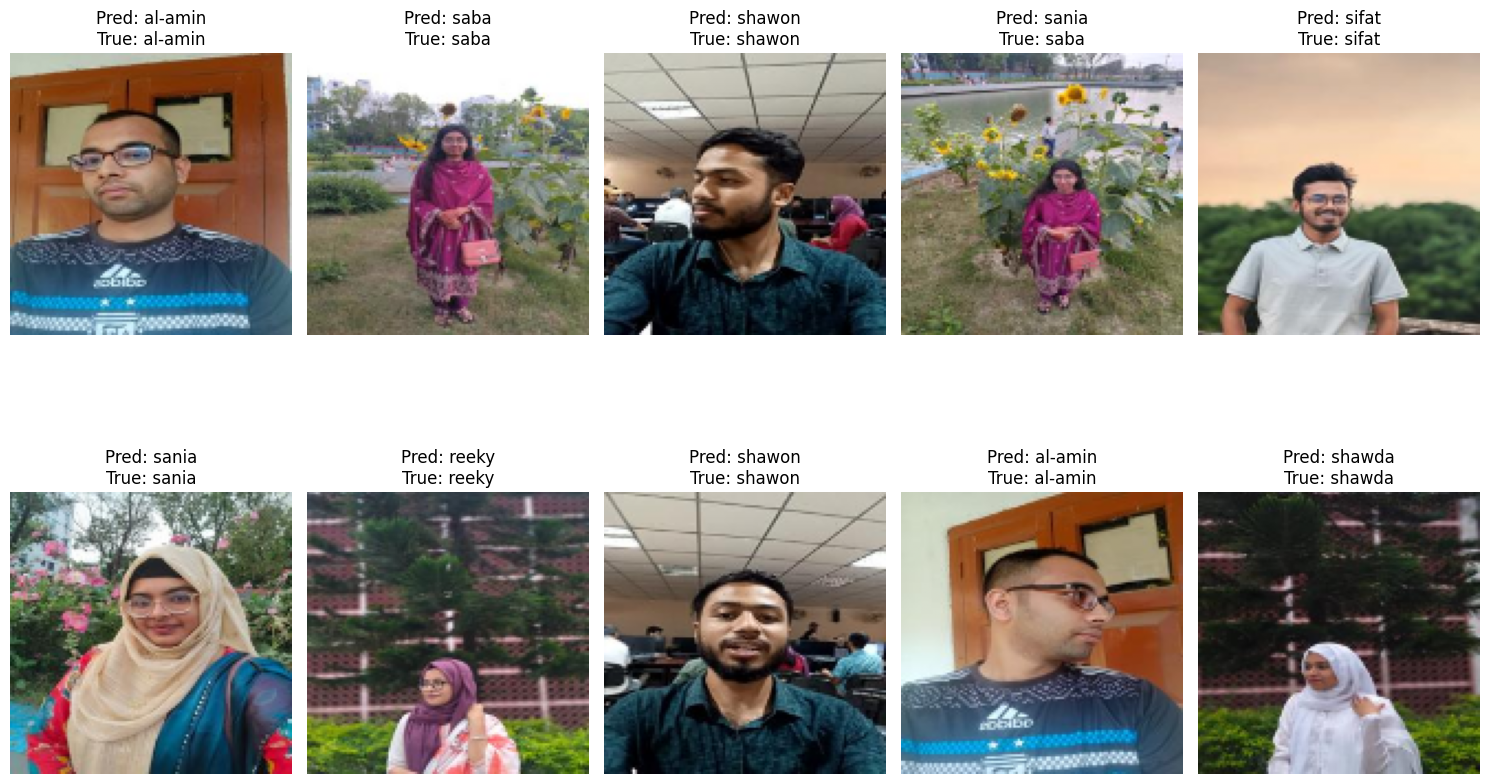

In [21]:
num_tests = min(10, len(data))
random_indices_face = random.sample(range(len(data)), num_tests)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices_face):
    test_face_img = data[idx]
    pred = face_model.predict(np.expand_dims(test_face_img, axis=0), verbose=0)
    pred_class = np.argmax(pred)
    true_class = labels[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(test_face_img)
    plt.title(f"Pred: {people[pred_class]}\nTrue: {people[true_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
face_explain_idx = random_indices_face[9]
test_face = data[face_explain_idx]
face_img_array = np.expand_dims(test_face, axis=0)

face_pred_probs = face_model.predict(face_img_array, verbose=0)
face_pred_class = np.argmax(face_pred_probs[0])

print(f"Explaining face image #{face_explain_idx}")
print(f"True label:      {people[labels[face_explain_idx]]}")
print(f"Predicted label: {people[face_pred_class]} (confidence {face_pred_probs[0][face_pred_class]:.3f})")

Explaining face image #24
True label:      shawda
Predicted label: shawda (confidence 0.989)


### Face — Grad-CAM

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_9']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


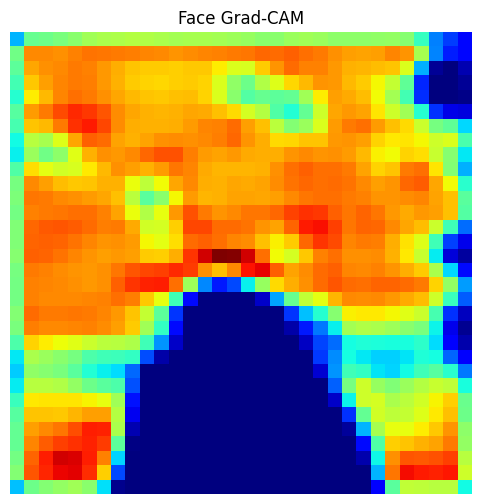

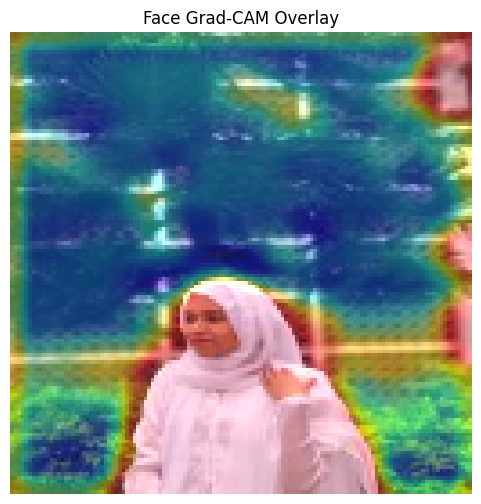

In [27]:
face_heatmap = make_gradcam_heatmap(
    face_img_array, face_model, "face_last_conv", "face_predictions", pred_index=face_pred_class
)

plt.figure(figsize=(6, 6))
plt.imshow(face_heatmap, cmap='jet')
plt.title("Face Grad-CAM")
plt.axis("off")
plt.show()

face_gradcam_overlay = overlay_heatmap(face_heatmap, test_face)
plt.figure(figsize=(6, 6))
plt.imshow(face_gradcam_overlay)
plt.title("Face Grad-CAM Overlay")
plt.axis("off")
plt.show()

### Face — CAM

The original notebook never applied CAM to the face classifier at all (only Grad-CAM and Integrated
Gradients) — added here for completeness, mirroring Part A.

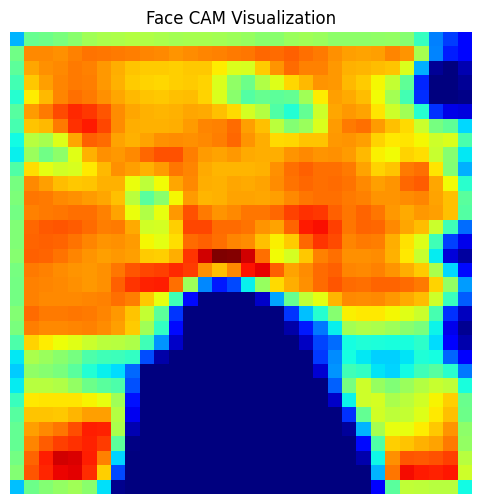

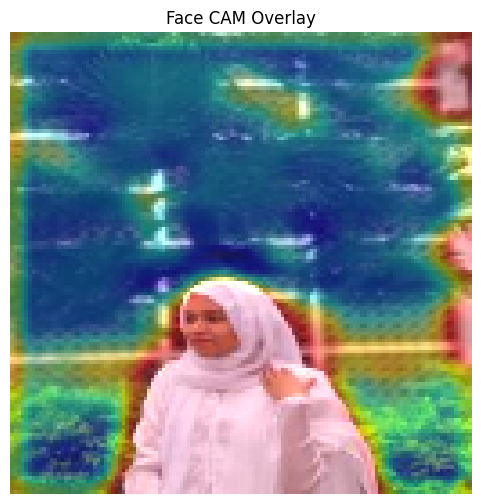

In [28]:
face_cam = make_cam_heatmap(
    face_img_array, face_model, "face_last_conv", "face_predictions", pred_index=face_pred_class
)

plt.figure(figsize=(6, 6))
plt.imshow(face_cam, cmap='jet')
plt.title("Face CAM Visualization")
plt.axis("off")
plt.show()

face_cam_overlay = overlay_heatmap(face_cam, test_face)
plt.figure(figsize=(6, 6))
plt.imshow(face_cam_overlay)
plt.title("Face CAM Overlay")
plt.axis("off")
plt.show()

### Face — Integrated Gradients

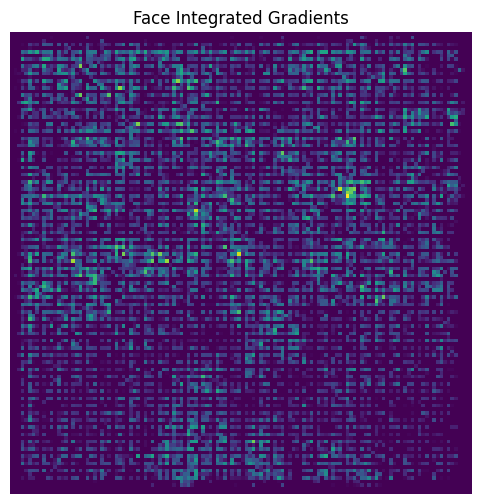

In [29]:
face_ig = IntegratedGradients()

face_ig_grid = face_ig.explain(
    validation_data=(face_img_array, None),
    model=face_model,
    class_index=int(face_pred_class)
)

plt.figure(figsize=(6, 6))
plt.imshow(face_ig_grid)
plt.title("Face Integrated Gradients")
plt.axis("off")
plt.show()